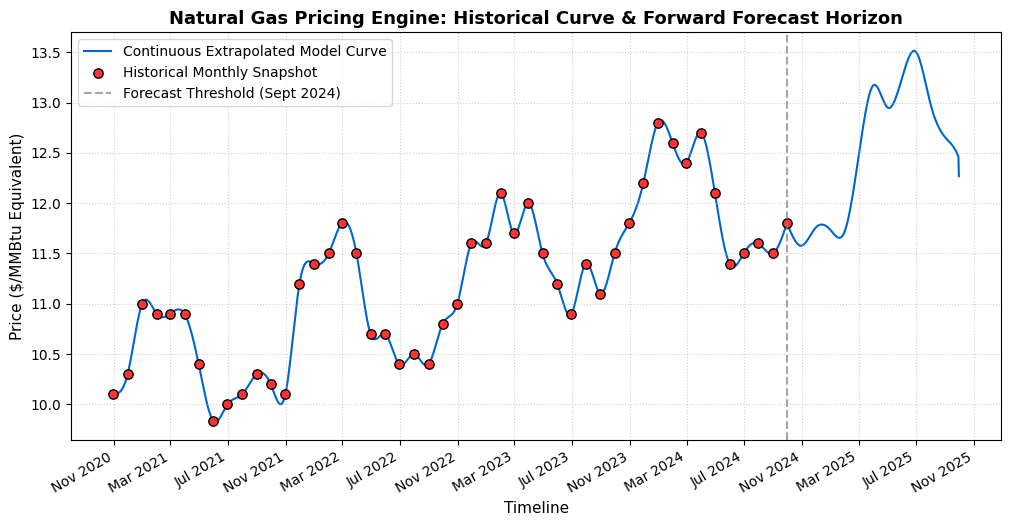


=== TRADING DESK TEST INTERPOLATIONS ===
Calculated pricing for 2021-06-15: $9.87
Calculated pricing for 2023-12-25: $12.73
Calculated pricing for 2025-01-15: $11.66
Calculated pricing for 2025-06-15: $13.44


In [4]:
import datetime
import io
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from sklearn.linear_model import LinearRegression

# =====================================================================
# DATA LOADING & INITIALIZATION
# =====================================================================

# Provided raw data string containing scientific notation format
csv_data = """Dates,Prices
10/31/20,1.01E+01
11/30/20,1.03E+01
12/31/20,1.10E+01
1/31/21,1.09E+01
2/28/21,1.09E+01
3/31/21,1.09E+01
4/30/21,1.04E+01
5/31/21,9.84E+00
6/30/21,1.00E+01
7/31/21,1.01E+01
8/31/21,1.03E+01
9/30/21,1.02E+01
10/31/21,1.01E+01
11/30/21,1.12E+01
12/31/21,1.14E+01
1/31/22,1.15E+01
2/28/22,1.18E+01
3/31/22,1.15E+01
4/30/22,1.07E+01
5/31/22,1.07E+01
6/30/22,1.04E+01
7/31/22,1.05E+01
8/31/22,1.04E+01
9/30/22,1.08E+01
10/31/22,1.10E+01
11/30/22,1.16E+01
12/31/22,1.16E+01
1/31/23,1.21E+01
2/28/23,1.17E+01
3/31/23,1.20E+01
4/30/23,1.15E+01
5/31/23,1.12E+01
6/30/23,1.09E+01
7/31/23,1.14E+01
8/31/23,1.11E+01
9/30/23,1.15E+01
10/31/23,1.18E+01
11/30/23,1.22E+01
12/31/23,1.28E+01
1/31/24,1.26E+01
2/29/24,1.24E+01
3/31/24,1.27E+01
4/30/24,1.21E+01
5/31/24,1.14E+01
6/30/24,1.15E+01
7/31/24,1.16E+01
8/31/24,1.15E+01
9/30/24,1.18E+01"""

# Read data from string
df = pd.read_csv(io.StringIO(csv_data))

# Format dates and sort sequentially
df["Dates"] = pd.to_datetime(df["Dates"], format="%m/%d/%y")
df = df.sort_values("Dates").reset_index(drop=True)

# Map dates to numerical timeline values (ordinal days) for continuous regression math
df["Ordinal"] = df["Dates"].apply(lambda x: x.toordinal())

# =====================================================================
# MODEL FITTING (TREND + SEASONALITY DETRENDING)
# =====================================================================

X_trend = df[["Ordinal"]].values
y_prices = df["Prices"].values

# 1. Isolate structural long-term linear price growth
trend_model = LinearRegression()
trend_model.fit(X_trend, y_prices)
df["Trend"] = trend_model.predict(X_trend)

# 2. Extract pure seasonal fluctuations (detrended residual wave)
df["Seasonal_Residual"] = df["Prices"] - df["Trend"]

# 3. Create a continuous daily map across existing timeframe using cubic splines
min_ord, max_ord = df["Ordinal"].min(), df["Ordinal"].max()
seasonal_spline = CubicSpline(
    df["Ordinal"], df["Seasonal_Residual"], bc_type="natural"
)


# =====================================================================
# CONTINUOUS PRICING FUNCTION (INTERPOLATION & EXTRAPOLATION)
# =====================================================================


def get_gas_price(input_date):
    """Calculates continuous estimated natural gas price for any date."""
    target_dt = pd.to_datetime(input_date)
    target_ord = target_dt.toordinal()

    # Base price prediction from the linear trend line
    predicted_trend = trend_model.predict(np.array([[target_ord]]))[0]

    # Map the seasonal factor safely (with annual wrapping for extrapolation out of boundaries)
    if target_ord > max_ord:
        days_past = target_ord - max_ord
        cycle_shift = days_past % 365
        mapped_ord = max_ord - cycle_shift
        seasonal_factor = seasonal_spline(mapped_ord)
    elif target_ord < min_ord:
        days_prior = min_ord - target_ord
        cycle_shift = days_prior % 365
        mapped_ord = min_ord + cycle_shift
        seasonal_factor = seasonal_spline(mapped_ord)
    else:
        # Standard intra-history date interpolation
        seasonal_factor = seasonal_spline(target_ord)

    return float(predicted_trend + seasonal_factor)


# =====================================================================
# GRAPH VISUALIZATION & FORECASTING
# =====================================================================

# Extend dates 1 full year past the final raw data point (Sept 2024 -> Sept 2025)
forecast_start = df["Dates"].min()
forecast_end = df["Dates"].max() + datetime.timedelta(days=365)
extended_timeline = pd.date_range(
    start=forecast_start, end=forecast_end, freq="D"
)

# Populate prices continuously across the entire duration
modeled_prices = [get_gas_price(day) for day in extended_timeline]

# Render the continuous curve vs raw data
plt.figure(figsize=(12, 6))
plt.plot(
    extended_timeline,
    modeled_prices,
    color="#0066cc",
    label="Continuous Extrapolated Model Curve",
    zorder=1,
)
plt.scatter(
    df["Dates"],
    df["Prices"],
    color="#ff3333",
    edgecolor="black",
    s=45,
    label="Historical Monthly Snapshot",
    zorder=2,
)

# Plot Polish Layout Details
plt.title(
    "Natural Gas Pricing Engine: Historical Curve & Forward Forecast Horizon",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Timeline", fontsize=11)
plt.ylabel("Price ($/MMBtu Equivalent)", fontsize=11)
plt.axvline(
    df["Dates"].max(),
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Forecast Threshold (Sept 2024)",
)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.show()

# =====================================================================
# VERIFICATION EXAMPLES FOR THE DESK
# =====================================================================
print("\n=== TRADING DESK TEST INTERPOLATIONS ===")
sample_queries = [
    "2021-06-15",  # Mid-summer history interpolation
    "2023-12-25",  # Peak-winter history interpolation
    "2025-01-15",  # Future winter contract extrapolation
    "2025-06-15",  # Future summer contract extrapolation
]

for q_date in sample_queries:
    print(f"Calculated pricing for {q_date}: ${get_gas_price(q_date):.2f}")